Proiect Econometrie Avansată

Studenti:
Constantin Teodor Vasile
Niţu Vlad Cristian

Tema: Analiza Economică a Riscului de Fraudă în Tranzacţii Financiare

Baza de date: https://www.kaggle.com/datasets/noopurbhatt/retail-intelligence-fraud-detection-dataset/data

In [14]:
# ============================================================
# Dependente: pandas, numpy, matplotlib, seaborn, scikit-learn, scipy, statsmodels
# pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde         
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

import warnings
warnings.filterwarnings("ignore") 
sns.set_theme(style="whitegrid", palette="muted")

In [15]:
# ------------------------------------------------------------
# 1. INCARCAREA DATELOR
# ------------------------------------------------------------
df = pd.read_csv("db.csv", parse_dates=["transaction_timestamp"])

print("=" * 150)
print("1. PRIVIRE DE ANSAMBLU")
print("=" * 150)
print(f"Numar randuri : {df.shape[0]:,}")
print(f"Numar coloane : {df.shape[1]}")
print("\nPrimele 5 randuri:")
print(df.head())

1. PRIVIRE DE ANSAMBLU
Numar randuri : 100,000
Numar coloane : 21

Primele 5 randuri:
  transaction_id customer_id      transaction_timestamp  transaction_amount  \
0       T0000001      C20953 2026-03-04 19:56:23.679173               56.31   
1       T0000002      C24133 2026-03-09 19:56:23.679330               20.35   
2       T0000003      C07165 2026-01-01 19:56:23.679362               48.72   
3       T0000004      C19310 2025-12-09 19:56:23.679385              153.62   
4       T0000005      C25019 2025-11-09 19:56:23.679409              115.32   

  payment_method device_type   location merchant_category  is_international  \
0     Debit Card      Tablet     Canada           Fashion                 0   
1    Credit Card      Tablet      India       Electronics                 0   
2     Debit Card      Tablet         UK            Travel                 0   
3     Debit Card      Mobile  Australia           Fashion                 0   
4         PayPal      Mobile      India     

In [16]:
# ------------------------------------------------------------
# 2. TIPURI DE DATE, VALORI LIPSA SI DROP LA COLOANELE NEFOLOSITOARE
# ------------------------------------------------------------

# Drop la coloanele care nu sunt relevante pentru analiza (ID-uri, timestamp)
df = df.drop(columns=["transaction_id", "customer_id", "transaction_timestamp"])

print("\n" + "=" * 150)
print("2. TIPURI DE DATE & VALORI LIPSA")
print("=" * 150)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({
    "tip_date": df.dtypes,
    "valori_lipsa": missing,
    "procent_lipsa (%)": missing_pct
})
print(summary)


2. TIPURI DE DATE & VALORI LIPSA
                                 tip_date  valori_lipsa  procent_lipsa (%)
transaction_amount                float64             0                0.0
payment_method                        str             0                0.0
device_type                           str             0                0.0
location                              str             0                0.0
merchant_category                     str             0                0.0
is_international                    int64             0                0.0
transaction_frequency_24h           int64             0                0.0
avg_transaction_amount_7d         float64             0                0.0
failed_transaction_count_24h        int64             0                0.0
account_age_days                    int64             0                0.0
previous_fraud_flag                 int64             0                0.0
unusual_amount_flag                 int64             0           

In [4]:
# -------------------------------------------------------------------------------------------------------------------------
# 2.5. VALORI LIPSA - IMPUTARE CU MEDIANA (Optional, doar daca exista valori lipsa in coloane numerice)
# -------------------------------------------------------------------------------------------------------------------------
# print("\n" + "=" * 150)
# print("3. VALORI LIPSA - IMPUTARE CU MEDIANA")
# print("=" * 150)

# # Verifica valorile lipsa inainte
# missing_before = df.isnull().sum()
# print("\nValori lipsa INAINTE de imputare:")
# print(missing_before[missing_before > 0] if missing_before.sum() > 0 else "  -> Nicio valoare lipsa gasita.")

# # Imputare cu mediana doar pentru coloanele numerice care au valori lipsa
# num_cols_with_missing = df.select_dtypes(include="number").columns[df.select_dtypes(include="number").isnull().any()]

# for col in num_cols_with_missing:
#     median_val = df[col].median()
#     df[col] = df[col].fillna(median_val)
#     print(f"  -> '{col}': imputat cu mediana = {median_val:.4f}")

# # Verifica valorile lipsa dupa
# missing_after = df.isnull().sum()
# print("\nValori lipsa DUPA imputare (coloane numerice):")
# print(missing_after[missing_after > 0] if missing_after.sum() > 0 else "  -> Nicio valoare lipsa ramasa in coloanele numerice.")

In [19]:
# ------------------------------------------------------------
# ENCODARE COLOANE BINARE
# ------------------------------------------------------------
binary_cols = [
    "is_international",
    "previous_fraud_flag",
    "unusual_amount_flag",
    "unusual_location_flag",
    "multiple_transactions_short_time",
    "high_risk_device_flag",
    "velocity_flag",
    "fraud_flag"
]
print(" ")
for col in binary_cols:
    df[col] = df[col].astype(int)
    unique_vals = sorted(df[col].unique().tolist())
    print(f"  '{col}': {unique_vals}")

print("\nTipuri de date dupa conversie:")
print(df[binary_cols].dtypes)

# ------------------------------------------------------------
# 4. STATISTICI DESCRIPTIVE
# ------------------------------------------------------------
print("\n" + "=" * 150)
print("4. STATISTICI DESCRIPTIVE")
print("=" * 150)

# Variabile numerice continue
num_cols = ["transaction_amount", "transaction_frequency_24h",
            "avg_transaction_amount_7d", "failed_transaction_count_24h",
            "account_age_days"]

print("\nVariabile numerice continue:")
print(df[num_cols].describe().round(2).T)

# Variabile binare - procentul de 1
print("\nVariabile binare (% valoare = 1):")
pct_series = (df[binary_cols].mean() * 100).round(2)
for col, val in pct_series.items():
    print(f"  {col}: {val}%")

# Variabile categoriale - numar categorii unice si top valoare
cat_cols = ["payment_method", "device_type", "location", "merchant_category", "fraud_risk"]

print("\nVariabile categoriale:")
for col in cat_cols:
    top_val = df[col].value_counts().idxmax()
    top_pct = df[col].value_counts(normalize=True).max() * 100
    n_unique = df[col].nunique()
    print(f"  '{col}': {n_unique} categorii unice | top: '{top_val}' ({top_pct:.1f}%)")

 
  'is_international': [0, 1]
  'previous_fraud_flag': [0, 1]
  'unusual_amount_flag': [0, 1]
  'unusual_location_flag': [0, 1]
  'multiple_transactions_short_time': [0, 1]
  'high_risk_device_flag': [0, 1]
  'velocity_flag': [0, 1]
  'fraud_flag': [0, 1]

Tipuri de date dupa conversie:
is_international                    int64
previous_fraud_flag                 int64
unusual_amount_flag                 int64
unusual_location_flag               int64
multiple_transactions_short_time    int64
high_risk_device_flag               int64
velocity_flag                       int64
fraud_flag                          int64
dtype: object

4. STATISTICI DESCRIPTIVE

Variabile numerice continue:
                                 count     mean     std   min     25%  \
transaction_amount            100000.0   120.48  119.79   0.0   34.82   
transaction_frequency_24h     100000.0     7.49    4.02   1.0    4.00   
avg_transaction_amount_7d     100000.0   109.81   51.89  20.0   64.91   
failed_trans

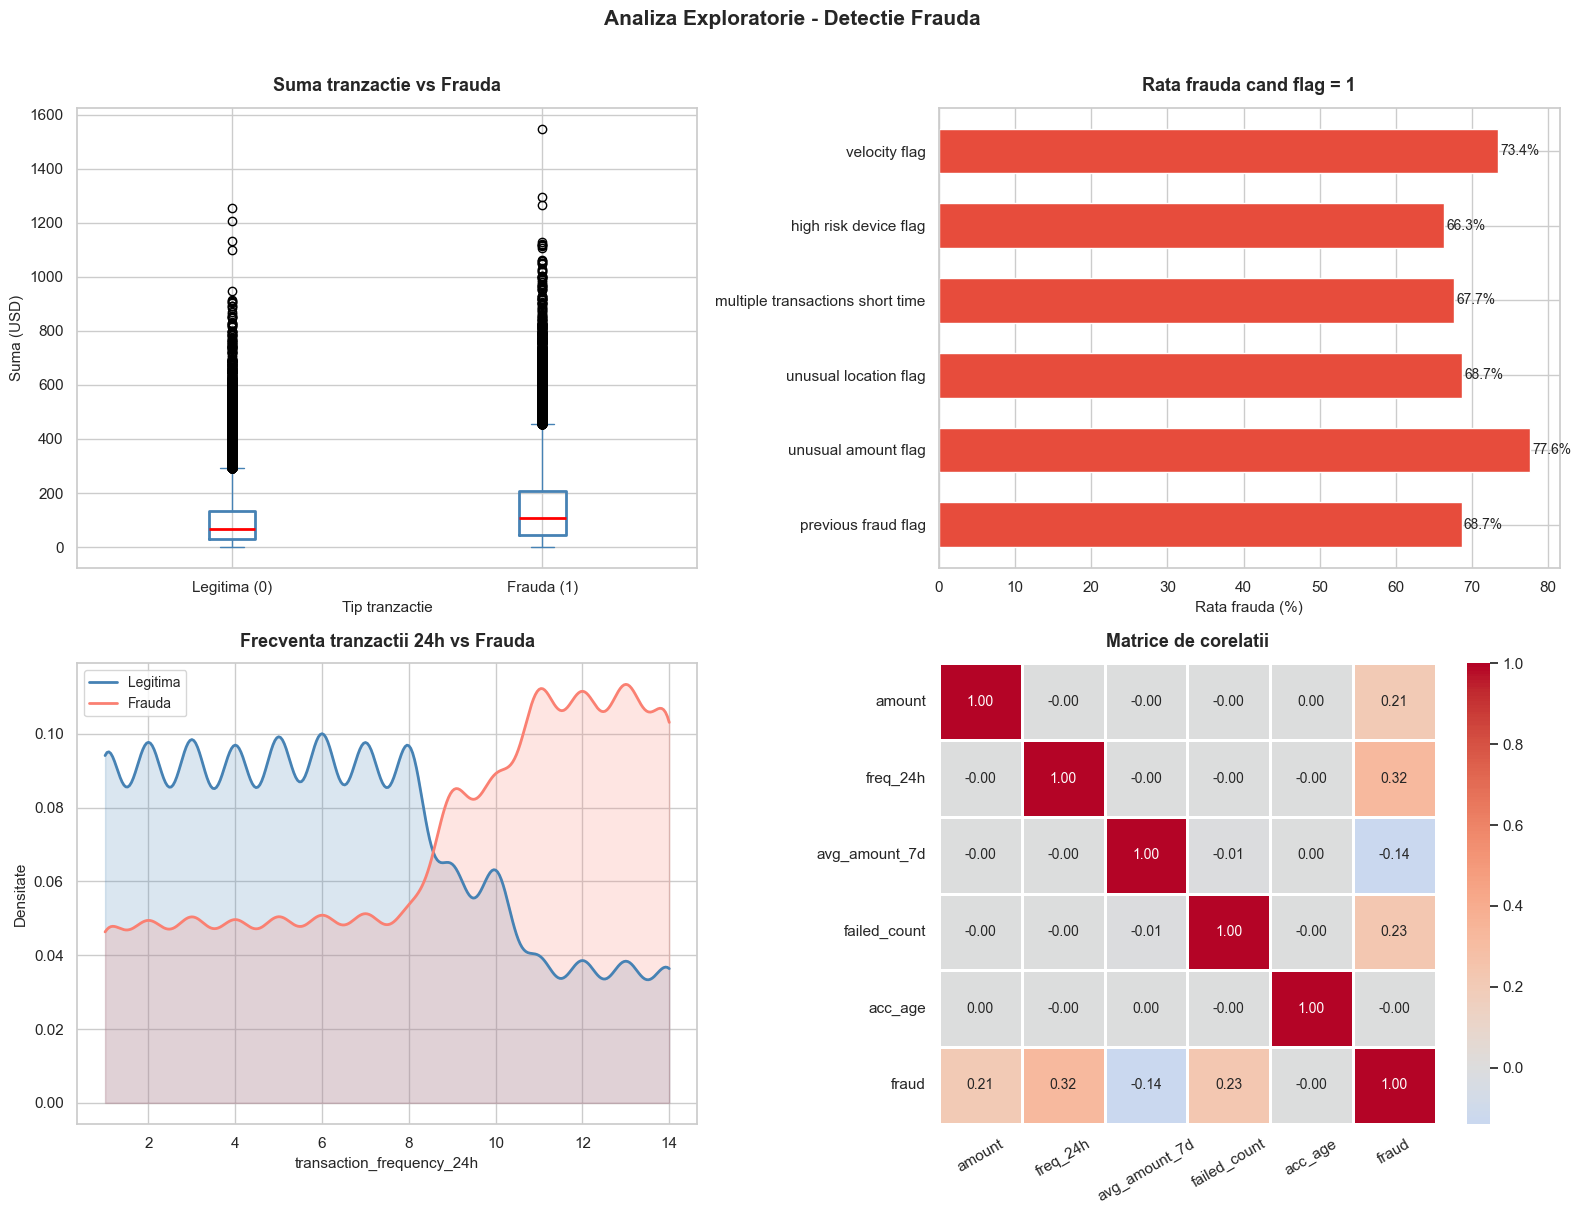

-> Salvat: plot_relevante.png


In [18]:
# ------------------------------------------------------------
# 5. GRAFICE RELEVANTE
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 1. Boxplot - Suma tranzactie vs Frauda
fraud_data = df[df["fraud_flag"] == 1]["transaction_amount"]
legit_data = df[df["fraud_flag"] == 0]["transaction_amount"]
axes[0].boxplot([legit_data, fraud_data], labels=["Legitima (0)", "Frauda (1)"],
                boxprops=dict(color="steelblue", linewidth=2),
                medianprops=dict(color="red", linewidth=2),
                whiskerprops=dict(color="steelblue"),
                capprops=dict(color="steelblue"))
axes[0].set_title("Suma tranzactie vs Frauda", fontsize=13, fontweight="bold", pad=12)
axes[0].set_ylabel("Suma (USD)", fontsize=11)
axes[0].set_xlabel("Tip tranzactie", fontsize=11)

# 2. Rata de frauda per flag comportamental
flag_cols = ["previous_fraud_flag", "unusual_amount_flag", "unusual_location_flag",
             "multiple_transactions_short_time", "high_risk_device_flag", "velocity_flag"]
flag_rates = {col: df[df[col] == 1]["fraud_flag"].mean() * 100 for col in flag_cols}
flag_labels = [col.replace("_", " ") for col in flag_rates.keys()]
colors = ["#e74c3c" if v > 20 else "#e67e22" if v > 10 else "#3498db" for v in flag_rates.values()]
bars = axes[1].barh(flag_labels, list(flag_rates.values()), color=colors, edgecolor="white", height=0.6)
axes[1].set_title("Rata frauda cand flag = 1", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Rata frauda (%)", fontsize=11)
for bar, val in zip(bars, flag_rates.values()):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=10)

# 3. KDE - Frecventa tranzactii 24h vs Frauda
legit_freq = df[df["fraud_flag"] == 0]["transaction_frequency_24h"]
fraud_freq  = df[df["fraud_flag"] == 1]["transaction_frequency_24h"]

for data, label, color in [(legit_freq, "Legitima", "steelblue"),
                            (fraud_freq, "Frauda", "salmon")]:
    kde = gaussian_kde(data)
    x   = np.linspace(data.min(), data.max(), 300)
    axes[2].plot(x, kde(x), label=label, color=color, linewidth=2)
    axes[2].fill_between(x, kde(x), alpha=0.2, color=color)

axes[2].set_title("Frecventa tranzactii 24h vs Frauda", fontsize=13, fontweight="bold", pad=12)
axes[2].set_xlabel("transaction_frequency_24h", fontsize=11)
axes[2].set_ylabel("Densitate", fontsize=11)
axes[2].legend(fontsize=10)

# 4. Heatmap - Matrice de corelatie
corr_cols = ["transaction_amount", "transaction_frequency_24h",
             "avg_transaction_amount_7d", "failed_transaction_count_24h",
             "account_age_days", "fraud_flag"]
corr_labels = ["amount", "freq_24h", "avg_amount_7d", "failed_count", "acc_age", "fraud"]
corr_matrix = df[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.8, linecolor="white",
            annot_kws={"size": 10}, ax=axes[3])
axes[3].set_title("Matrice de corelatii", fontsize=13, fontweight="bold", pad=12)
axes[3].tick_params(axis="x", rotation=30)
axes[3].tick_params(axis="y", rotation=0)

plt.suptitle("Analiza Exploratorie - Detectie Frauda", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_relevante.png", dpi=150, bbox_inches="tight")
plt.show()
print("-> Salvat: plot_relevante.png")

In [20]:
# ------------------------------------------------------------
# 6. PREGATIRE DATE PENTRU REGRESIE LOGISTICA
# ------------------------------------------------------------

TARGET = "fraud_flag"

cat_cols = [
    "payment_method",
    "device_type",
    "location",
    "merchant_category"
]
cat_cols = [c for c in cat_cols if c in df.columns]

# Excludem fraud_risk si flag-urile de risc pentru a evita data leakage,
# coliniaritate perfecta si perfect/quasi-perfect separation.
rule_flag_cols = [
    "is_international",
    "previous_fraud_flag",
    "unusual_amount_flag",
    "unusual_location_flag",
    "multiple_transactions_short_time",
    "high_risk_device_flag",
    "velocity_flag",
]
cols_to_drop = ["fraud_risk"] + rule_flag_cols
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_logit = pd.get_dummies(
    df.drop(columns=cols_to_drop),
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

X = df_logit.drop(columns=[TARGET])
y = df_logit[TARGET].astype(int)

# Eliminam coloane constante si adaugam intercept.
X = X.loc[:, X.nunique() > 1]
X = sm.add_constant(X.astype(float), has_constant="add")

print(f"Features folosite: {X.shape[1] - 1}")
print(X.dtypes.value_counts())


Features folosite: 21
float64    22
Name: count, dtype: int64


In [24]:
# ------------------------------------------------------------
# 7. REGRESIE LOGISTICA
# ------------------------------------------------------------

model = sm.Logit(y, X)
result = model.fit(maxiter=1000, disp=True)

print(result.summary())

# Extragere tabel coeficienți
summary_table = result.summary2().tables[1]

def significance_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

# 1. Resetăm indexul pentru a putea modifica numele variabilelor (care sunt pe post de index)
summary_table = summary_table.reset_index()

# 2. Generăm steluțele pe baza p-value
summary_table["Signif"] = summary_table["P>|z|"].apply(significance_stars)

# 3. Lipim steluțele de numele variabilei (coloana 'index')
summary_table["Variable"] = summary_table["index"] + summary_table["Signif"]

# 4. Punem noul nume înapoi ca index al tabelului
summary_table = summary_table.set_index("Variable")

# Păstrăm coeficienții ca numere (doar îi rotunjim pentru aspect)
summary_table["Coef."] = summary_table["Coef."].round(4)

# Afisare tabel final cu coloanele dorite
final_table = summary_table[
    ["Coef.", "Std.Err.", "z", "P>|z|"]
]

print("\nTABEL FINAL CU SEMNIFICATIE STATISTICA (PE NUME):\n")
print(final_table)

Optimization terminated successfully.
         Current function value: 0.566794
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             fraud_flag   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99978
Method:                           MLE   Df Model:                           21
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.1808
Time:                        19:37:00   Log-Likelihood:                -56679.
converged:                       True   LL-Null:                       -69190.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.3908      0.041    -58.047      0.000

In [25]:
# ------------------------------------------------------------
# 8. REGRESIE LOGISTICA CU VARIABILE SEMNIFICATIVE (p < 0.1)
# ------------------------------------------------------------

p_threshold = 0.10

significant_vars = result.pvalues[result.pvalues < p_threshold].index.tolist()
significant_vars = [var for var in significant_vars if var != "const"]

print(f"Variabile selectate cu p-value < {p_threshold}:")
print(significant_vars)
print(f"Numar variabile selectate: {len(significant_vars)}")

X_sig = X[["const"] + significant_vars]

model_sig = sm.Logit(y, X_sig)
result_sig = model_sig.fit(maxiter=1000, disp=True)

print(result_sig.summary())


Variabile selectate cu p-value < 0.1:
['transaction_amount', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'device_type_Mobile', 'device_type_Tablet', 'location_USA']
Numar variabile selectate: 7
Optimization terminated successfully.
         Current function value: 0.566831
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             fraud_flag   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99992
Method:                           MLE   Df Model:                            7
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.1808
Time:                        19:37:33   Log-Likelihood:                -56683.
converged:                       True   LL-Null:                       -69190.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          

In [26]:
# ------------------------------------------------------------
# 9. ERROR ANALYSIS PENTRU MODELUL CU VARIABILE SEMNIFICATIVE
# ------------------------------------------------------------

threshold = 0.50

y_prob_sig = result_sig.predict(X_sig)
y_pred_sig = (y_prob_sig >= threshold).astype(int)

print(f"Threshold folosit: {threshold}")
print("\nConfusion matrix:")
cm = confusion_matrix(y, y_pred_sig)
print(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

print("\nClassification report:")
print(classification_report(y, y_pred_sig, digits=4))

print(f"ROC-AUC           : {roc_auc_score(y, y_prob_sig):.4f}")
print(f"Average precision : {average_precision_score(y, y_prob_sig):.4f}")

# Construim tabel de erori
error_df = df_logit.copy()
error_df["y_actual"] = y.values
error_df["y_prob"] = y_prob_sig
error_df["y_pred"] = y_pred_sig.values
error_df["error_type"] = np.select(
    [
        (error_df["y_actual"] == 0) & (error_df["y_pred"] == 1),
        (error_df["y_actual"] == 1) & (error_df["y_pred"] == 0),
        (error_df["y_actual"] == 1) & (error_df["y_pred"] == 1),
        (error_df["y_actual"] == 0) & (error_df["y_pred"] == 0),
    ],
    ["False Positive", "False Negative", "True Positive", "True Negative"],
    default="Unknown"
)

print("\nNumar cazuri pe tip de clasificare:")
print(error_df["error_type"].value_counts())

analysis_cols = [
    "transaction_amount",
    "transaction_frequency_24h",
    "avg_transaction_amount_7d",
    "failed_transaction_count_24h",
    "account_age_days",
    "y_prob"
]
analysis_cols = [c for c in analysis_cols if c in error_df.columns]

print("\nMedii pe tip de clasificare:")
print(error_df.groupby("error_type")[analysis_cols].mean().round(3))

print("\nCele mai sigure false positives:")
print(error_df[error_df["error_type"] == "False Positive"]
      .sort_values("y_prob", ascending=False)
      [analysis_cols + ["y_actual", "y_pred"]]
      .head(10)
      .round(3))

print("\nCele mai sigure false negatives:")
print(error_df[error_df["error_type"] == "False Negative"]
      .sort_values("y_prob", ascending=True)
      [analysis_cols + ["y_actual", "y_pred"]]
      .head(10)
      .round(3))


Threshold folosit: 0.5

Confusion matrix:
          Predicted 0  Predicted 1
Actual 0        39082        13410
Actual 1        15480        32028

Classification report:
              precision    recall  f1-score   support

           0     0.7163    0.7445    0.7301     52492
           1     0.7049    0.6742    0.6892     47508

    accuracy                         0.7111    100000
   macro avg     0.7106    0.7093    0.7097    100000
weighted avg     0.7109    0.7111    0.7107    100000

ROC-AUC           : 0.7757
Average precision : 0.7606

Numar cazuri pe tip de clasificare:
error_type
True Negative     39082
True Positive     32028
False Negative    15480
False Positive    13410
Name: count, dtype: int64

Medii pe tip de clasificare:
                transaction_amount  transaction_frequency_24h  \
error_type                                                      
False Negative              94.249                      5.719   
False Positive             142.875                   

In [27]:
# ------------------------------------------------------------
# 10. MODEL ALTERNATIV: CU FLAG-URI DE RISC
# ------------------------------------------------------------

# Acest model pastreaza flag-urile de risc pentru comparatie cu modelul curat.
# Excludem in continuare fraud_risk si is_international:
# - fraud_risk este prea apropiat de target
# - is_international este identic cu unusual_location_flag
cols_to_drop_full = [c for c in ["fraud_risk", "is_international"] if c in df.columns]

cat_cols_full = [
    "payment_method",
    "device_type",
    "location",
    "merchant_category"
]
cat_cols_full = [c for c in cat_cols_full if c in df.columns]

df_logit_full = pd.get_dummies(
    df.drop(columns=cols_to_drop_full),
    columns=cat_cols_full,
    drop_first=True,
    dtype=int
)

X_full = df_logit_full.drop(columns=[TARGET])
y_full = df_logit_full[TARGET].astype(int)

X_full = X_full.loc[:, X_full.nunique() > 1]
X_full = sm.add_constant(X_full.astype(float), has_constant="add")

print(f"Features folosite: {X_full.shape[1] - 1}")

model_full = sm.Logit(y_full, X_full)

try:
    result_full = model_full.fit(maxiter=1000, disp=True)
    model_full_method = "standard Logit"
except np.linalg.LinAlgError:
    print("Matrice singulara detectata; folosim fit_regularized pentru modelul cu flag-uri de risc.")
    result_full = model_full.fit_regularized(method="l1", alpha=0.1, maxiter=1000, disp=True)
    model_full_method = "regularized Logit"

print(f"Metoda folosita: {model_full_method}")
print(result_full.summary())


Features folosite: 27
         Current function value: inf
         Iterations: 1000
Matrice singulara detectata; folosim fit_regularized pentru modelul cu flag-uri de risc.
Iteration limit reached    (Exit mode 9)
            Current function value: 0.0005077082429218375
            Iterations: 1000
            Function evaluations: 1014
            Gradient evaluations: 1001
Metoda folosita: regularized Logit
                           Logit Regression Results                           
Dep. Variable:             fraud_flag   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99972
Method:                           MLE   Df Model:                           27
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.9999
Time:                        19:39:09   Log-Likelihood:                -5.6201
converged:                      False   LL-Null:                       -69190.
Covariance Type:            nonr

In [28]:
# ------------------------------------------------------------
# 11. RANDOM FOREST - MODEL PREDICTIV
# ------------------------------------------------------------

# Folosim acelasi set curat de predictori ca la regresia logistica principala.
X_rf = df_logit.drop(columns=[TARGET]).astype(float)
y_rf = df_logit[TARGET].astype(int)

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.20,
    random_state=42,
    stratify=y_rf
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train_rf, y_train_rf)

rf_prob = rf_model.predict_proba(X_test_rf)[:, 1]
rf_pred = (rf_prob >= 0.50).astype(int)

print("Random Forest - rezultate pe setul de test")
print("\nConfusion matrix:")
rf_cm = confusion_matrix(y_test_rf, rf_pred)
print(pd.DataFrame(
    rf_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

print("\nClassification report:")
print(classification_report(y_test_rf, rf_pred, digits=4))

print(f"ROC-AUC           : {roc_auc_score(y_test_rf, rf_prob):.4f}")
print(f"Average precision : {average_precision_score(y_test_rf, rf_prob):.4f}")

rf_importance = pd.DataFrame({
    "feature": X_rf.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 variabile dupa importanta Random Forest:")
print(rf_importance.head(15).to_string(index=False, float_format="{:.4f}".format))


Random Forest - rezultate pe setul de test

Confusion matrix:
          Predicted 0  Predicted 1
Actual 0         8434         2064
Actual 1         2637         6865

Classification report:
              precision    recall  f1-score   support

           0     0.7618    0.8034    0.7820     10498
           1     0.7688    0.7225    0.7449      9502

    accuracy                         0.7650     20000
   macro avg     0.7653    0.7629    0.7635     20000
weighted avg     0.7652    0.7650    0.7644     20000

ROC-AUC           : 0.8118
Average precision : 0.8027

Top 15 variabile dupa importanta Random Forest:
                     feature  importance
   transaction_frequency_24h      0.3775
failed_transaction_count_24h      0.2141
          transaction_amount      0.1915
   avg_transaction_amount_7d      0.1190
            account_age_days      0.0419
          device_type_Mobile      0.0128
          device_type_Tablet      0.0042
       payment_method_PayPal      0.0032
   payment

In [29]:
# ------------------------------------------------------------
# 12. DIAGNOSTICE MODEL: HETEROSKEDASTICITATE, AUTOCORRELATIE, NORMALITATE, MULTICOLINIARITATE
# ------------------------------------------------------------

from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2, jarque_bera, shapiro, skew, kurtosis

print("Nota: Breusch-Pagan si Durbin-Watson sunt teste clasice pentru OLS.")
print("Pentru Logit le folosim doar ca diagnostice pe reziduuri, nu ca teste decisive de validitate.\n")


def hosmer_lemeshow_test(y_true, y_prob, groups=10):
    hl_df = pd.DataFrame({"y": y_true, "prob": y_prob})
    hl_df["group"] = pd.qcut(hl_df["prob"], q=groups, duplicates="drop")

    grouped = hl_df.groupby("group", observed=True)
    observed = grouped["y"].sum()
    expected = grouped["prob"].sum()
    n = grouped.size()

    eps = 1e-10
    hl_stat = (((observed - expected) ** 2) / (expected + eps) +
               (((n - observed) - (n - expected)) ** 2) / ((n - expected) + eps)).sum()
    dof = max(len(observed) - 2, 1)
    p_value = 1 - chi2.cdf(hl_stat, dof)

    table = pd.DataFrame({
        "n": n,
        "observed_fraud": observed,
        "expected_fraud": expected,
        "observed_rate": observed / n,
        "mean_predicted_prob": grouped["prob"].mean()
    })

    return hl_stat, dof, p_value, table


def vif_table(X_model):
    X_no_const = X_model.drop(columns=["const"], errors="ignore")
    vif_values = []
    for i, col in enumerate(X_no_const.columns):
        vif_values.append({
            "feature": col,
            "VIF": variance_inflation_factor(X_no_const.values, i)
        })
    return pd.DataFrame(vif_values).sort_values("VIF", ascending=False)


def run_logit_diagnostics(model_name, X_model, y_true, fitted_result):
    print("=" * 100)
    print(model_name)
    print("=" * 100)

    y_prob = fitted_result.predict(X_model)
    residuals = y_true - y_prob

    # 1. Heteroskedasticity-style residual diagnostic
    bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(residuals, X_model)
    print("\nBreusch-Pagan pe reziduuri:")
    print(f"  LM statistic : {bp_lm:.4f}")
    print(f"  LM p-value   : {bp_lm_pvalue:.4g}")
    print(f"  F statistic  : {bp_fvalue:.4f}")
    print(f"  F p-value    : {bp_f_pvalue:.4g}")

    # 2. Autocorrelation diagnostics. Interpretarea depinde de ordinea randurilor.
    dw_stat = durbin_watson(residuals)
    print("\nAutocorelatie reziduuri:")
    print(f"  Durbin-Watson: {dw_stat:.4f}")
    print("  Ljung-Box:")
    print(acorr_ljungbox(residuals, lags=[1, 5, 10], return_df=True).round(4))

    # 3. Normality diagnostics. Normalitatea reziduurilor nu este o presupunere a modelului Logit.
    jb_stat, jb_pvalue = jarque_bera(residuals)
    sample_for_shapiro = residuals.sample(n=min(5000, len(residuals)), random_state=42)
    shapiro_stat, shapiro_pvalue = shapiro(sample_for_shapiro)

    print("\nNormalitate reziduuri:")
    print(f"  Jarque-Bera statistic : {jb_stat:.4f}")
    print(f"  Jarque-Bera p-value   : {jb_pvalue:.4g}")
    print(f"  Shapiro-Wilk statistic: {shapiro_stat:.4f} (calculat pe max. 5000 obs.)")
    print(f"  Shapiro-Wilk p-value  : {shapiro_pvalue:.4g}")
    print(f"  Skewness              : {skew(residuals):.4f}")
    print(f"  Kurtosis              : {kurtosis(residuals, fisher=False):.4f}")

    # 4. Multicollinearity
    print("\nVIF - top 15:")
    print(vif_table(X_model).head(15).to_string(index=False, float_format="{:.4f}".format))

    # 5. Condition number
    cond_number = np.linalg.cond(X_model.values)
    print(f"\nCondition number: {cond_number:.2f}")

    # 6. Calibration diagnostic
    hl_stat, hl_dof, hl_pvalue, hl_table = hosmer_lemeshow_test(y_true, y_prob, groups=10)
    print("\nHosmer-Lemeshow calibration test:")
    print(f"  HL statistic : {hl_stat:.4f}")
    print(f"  df           : {hl_dof}")
    print(f"  p-value      : {hl_pvalue:.4g}")
    print("\nTabel calibrare pe decile:")
    print(hl_table.round(4))


run_logit_diagnostics("Model Logit curat - toate variabilele", X, y, result)
run_logit_diagnostics("Model Logit curat - doar variabile cu p < 0.1", X_sig, y, result_sig)



Nota: Breusch-Pagan si Durbin-Watson sunt teste clasice pentru OLS.
Pentru Logit le folosim doar ca diagnostice pe reziduuri, nu ca teste decisive de validitate.

Model Logit curat - toate variabilele

Breusch-Pagan pe reziduuri:
  LM statistic : 705.1256
  LM p-value   : 1.097e-135
  F statistic  : 33.8084
  F p-value    : 3.397e-136

Autocorelatie reziduuri:
  Durbin-Watson: 2.0097
  Ljung-Box:
    lb_stat  lb_pvalue
1    2.3733     0.1234
5    7.1913     0.2068
10  15.1330     0.1273

Normalitate reziduuri:
  Jarque-Bera statistic : 4754.3734
  Jarque-Bera p-value   : 0
  Shapiro-Wilk statistic: 0.9709 (calculat pe max. 5000 obs.)
  Shapiro-Wilk p-value  : 1.094e-30
  Skewness              : 0.1133
  Kurtosis              : 1.9561

VIF - top 15:
                     feature    VIF
   avg_transaction_amount_7d 4.6801
   transaction_frequency_24h 3.9741
            account_age_days 3.6684
failed_transaction_count_24h 2.8008
          transaction_amount 1.9479
          device_type_Mob

# Interpretarea rezultatelor

Analiza arata ca variabila `fraud_flag` trebuie tratata cu prudenta. Modelul care include flag-urile de risc produce o potrivire aproape perfecta, cu pseudo R² foarte mare si avertismente de quasi-separation. Acest lucru sugereaza ca o parte dintre aceste variabile nu sunt predictori independenti, ci sunt probabil legate direct de modul in care tranzactiile au fost marcate ca frauduloase. De aceea, pentru interpretarea econometrica principala este mai potrivit modelul curat, in care `fraud_risk` si flag-urile de risc au fost eliminate.

Modelul Logit curat are un McFadden pseudo R² de aproximativ 0.18. Desi pare mic in comparatie cu R²-ul din regresia liniara, pentru regresia logistica aceasta valoare indica o capacitate explicativa rezonabila. Modelul nu mai prezinta probleme majore de coliniaritate sau separare perfecta, iar coeficientii si p-value-urile sunt mai stabile si mai usor de interpretat. Modelul redus, care pastreaza doar variabilele cu p-value sub 0.1, ofera aproape aceeasi performanta, dar cu mai putine variabile, deci poate fi folosit ca specificatie mai parsimonioasa.

Diagnosticele arata ca nu exista dovezi importante de autocorelatie a reziduurilor: Durbin-Watson este aproape de 2, iar testele Ljung-Box nu sunt semnificative. VIF-urile sunt sub pragul uzual de 5, deci multicoliniaritatea nu pare sa fie o problema serioasa. Testele Breusch-Pagan si de normalitate sunt semnificative, dar acestea sunt teste clasice pentru OLS si nu reprezinta ipoteze fundamentale pentru regresia logistica, unde variabila dependenta este binara. Testul Hosmer-Lemeshow respinge calibrarea perfecta, insa la un esantion de 100.000 de observatii acest test este foarte sensibil; tabelul pe decile arata totusi ca probabilitatile estimate sunt relativ apropiate de ratele observate.

Modelul Random Forest a fost evaluat pe un set de test si are rezultate bune pentru un model fara flag-uri de risc: acuratete aproximativ 76.5%, ROC-AUC aproximativ 0.812 si average precision aproximativ 0.803. Pentru clasa de frauda, recall-ul este aproximativ 72.3%, iar precision-ul aproximativ 76.9%. Cele mai importante variabile sunt `transaction_frequency_24h`, `failed_transaction_count_24h`, `transaction_amount` si `avg_transaction_amount_7d`, ceea ce sugereaza ca variabilele comportamentale ale tranzactiei sunt mai informative decat variabilele categoriale precum metoda de plata, locatia sau categoria comerciantului.

Concluzia principala este ca modelul Logit curat este mai potrivit pentru interpretare econometrica, deoarece evita leakage-ul si separarea perfecta, in timp ce Random Forest este mai potrivit pentru comparatie predictiva. Modelul cu flag-uri de risc poate fi prezentat doar ca analiza alternativa, demonstrand ca aceste flag-uri aproape determina `fraud_flag`, dar nu ar trebui folosit ca model principal de inferenta.
